# 02 — Polynomial Regression

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Load & Preprocess

In [2]:
df = pd.read_csv('Sleep_health_and_lifestyle_dataset.csv')
df = df.drop('Person ID', axis=1)
df = df.drop('Blood Pressure', axis=1)

le = LabelEncoder()
df['Gender']        = le.fit_transform(df['Gender'])
df['Occupation']    = le.fit_transform(df['Occupation'])
df['BMI Category']  = le.fit_transform(df['BMI Category'])
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')
df['Sleep Disorder'] = le.fit_transform(df['Sleep Disorder'])

X = df.drop(['Quality of Sleep', 'Sleep Disorder'], axis=1)
y = df['Quality of Sleep']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (299, 9) | Test: (75, 9)


## Apply Polynomial Features (degree=2)

In [3]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly  = poly.transform(X_test)

print('Original features:', X_train.shape[1])
print('Polynomial features:', X_train_poly.shape[1])

Original features: 9
Polynomial features: 54


## Train Model

In [4]:
model = LinearRegression()
model.fit(X_train_poly, y_train)
y_pred = model.predict(X_test_poly)

## Evaluation

In [5]:
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print('Polynomial Regression (degree=2) — Quality of Sleep')
print(f'  MAE  : {mae:.4f}')
print(f'  MSE  : {mse:.4f}')
print(f'  RMSE : {rmse:.4f}')
print(f'  R²   : {r2:.4f}')

Polynomial Regression (degree=2) — Quality of Sleep
  MAE  : 0.1009
  MSE  : 0.1018
  RMSE : 0.3191
  R²   : 0.9325


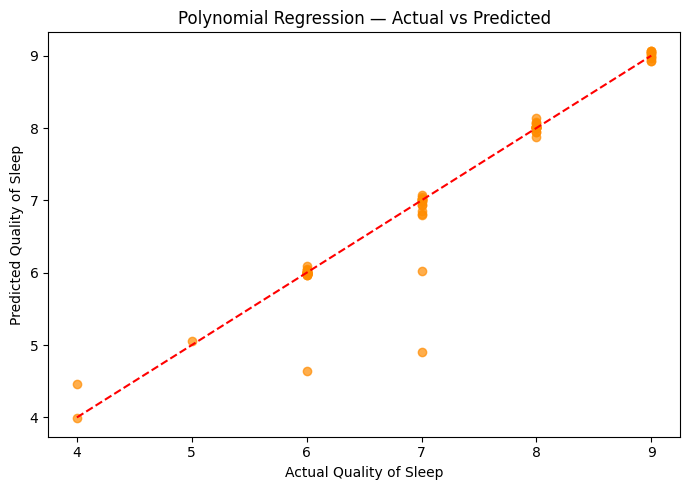

In [6]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, y_pred, color='darkorange', alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Quality of Sleep')
plt.ylabel('Predicted Quality of Sleep')
plt.title('Polynomial Regression — Actual vs Predicted')
plt.tight_layout()
plt.show()